# Solar Project

## Connect to cloud storage

In [8]:
ENDPOINT           = 'https://nyu1.osn.mghpcc.org'
EAEEE4000_PROFILE  = 'eaeee4000'
LEAPBUCKET         = 'leap-edu-test'
NYC4URBAN_ZARR_DIR = 'nyc4urban/nyc4urban.zarr'
import fsspec
import fsspec, os
fs = fsspec.filesystem(
    's3',
    anon          = False,
    profile       = EAEEE4000_PROFILE,
    client_kwargs = {'endpoint_url': ENDPOINT}
)
fs_mapper = fs.get_mapper(
    os.path.join(LEAPBUCKET, NYC4URBAN_ZARR_DIR)
)
fs.ls('leap-edu-test')

['leap-edu-test/nyc4urban']

In [9]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import xarray
xar = xarray.open_dataset(fs_mapper, engine='zarr', chunks={}).to_array()
xar
# remove auxiliary dataset dimension
xar = xar[0,...]
xar.shape

(30537, 29, 288, 288)

## Model building

In [11]:
import numpy as np
import xarray as xr
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class BuildingDataset(Dataset):
    def __init__(self, xar_data, indices):
        """
        Dataset initialization
        Args:
            xar_data: xarray dataset
            indices: indices of the data samples
        """
        self.xar_data = xar_data
        self.indices = indices
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        # Extract data at the specified index
        data = self.xar_data[self.indices[idx]]
        
        # Multispectral data (Red, Green, Blue, Near-Infrared)
        # Layer 1, 3, 5, 7 correspond to Red, Green, Blue, NIR respectively
        image = np.stack([
            data[1].values,  # Red
            data[3].values,  # Green
            data[5].values,  # Blue
            data[7].values   # NIR
        ]).astype(np.float32)
        
        # Normalize image data to [0, 1]
        image = image / np.max(image)
        
        # Extract building mask (Layer 29)
        mask = (data[28].values == 5).astype(np.float32)  # Building is 1, others are 0
        
        # Convert to PyTorch tensors
        image = torch.from_numpy(image)  # shape: (4, 288, 288)
        mask = torch.from_numpy(mask).unsqueeze(0)  # shape: (1, 288, 288)
        
        return image, mask


In [12]:
class BuildingDataset(Dataset):
    def __init__(self, xar_data, indices):
        """
        Dataset initialization
        Args:
            xar_data: xarray dataset
            indices: indices of the data samples
        """
        self.xar_data = xar_data
        self.indices = indices
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        # Extract data at the specified index
        data = self.xar_data[self.indices[idx]]
        
        # Multispectral data (Red, Green, Blue, Near-Infrared)
        # Layer 1, 3, 5, 7 correspond to Red, Green, Blue, NIR respectively
        image = np.stack([
            data[1].values,  # Red
            data[3].values,  # Green
            data[5].values,  # Blue
            data[7].values   # NIR
        ]).astype(np.float32)
        
        # Normalize image data to [0, 1]
        image = image / np.max(image)
        
        # Extract building mask (Layer 29)
        mask = (data[28].values == 5).astype(np.float32)  # Building is 1, others are 0
        
        # Convert to PyTorch tensors
        image = torch.from_numpy(image)  # shape: (4, 288, 288)
        mask = torch.from_numpy(mask).unsqueeze(0)  # shape: (1, 288, 288)
        
        return image, mask


In [13]:
def prepare_data_loaders(xar_data, batch_size=8, sample_limit=1000):
    """
    Prepare training, validation, and test data loaders, with support for limiting the sample size
    
    Args:
        xar_data: Dataset in xarray format
        batch_size: Number of samples per batch
        sample_limit: Limit on the total number of samples to use; use all samples if None
    
    Returns:
        train_loader, val_loader, test_loader: Three data loaders
    """
    # Get all available indices
    total_indices = np.arange(xar_data.shape[0])
    
    # Sample the dataset if a limit is set
    if sample_limit is not None:
        # Ensure sample_limit does not exceed the total number of samples
        sample_limit = min(sample_limit, len(total_indices))
        # Randomly select the specified number of samples
        selected_indices = np.random.choice(
            total_indices, 
            size=sample_limit, 
            replace=False
        )
    else:
        selected_indices = total_indices
    
    # Print the actual number of samples being used
    print(f"\nNumber of samples being used: {len(selected_indices)}")
    
    # Split the dataset (maintaining original proportions)
    train_val_indices, test_indices = train_test_split(
        selected_indices,
        test_size=0.2,
        random_state=42
    )
    
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=0.25,
        random_state=42
    )
    
    # Create dataset instances
    train_dataset = BuildingDataset(xar_data, train_indices)
    val_dataset = BuildingDataset(xar_data, val_indices)
    test_dataset = BuildingDataset(xar_data, test_indices)
    
    # Print dataset split details
    print("\nDataset split details:")
    print(f"Training set: {len(train_dataset)} samples ({len(train_dataset)/len(selected_indices)*100:.1f}%)")
    print(f"Validation set: {len(val_dataset)} samples ({len(val_dataset)/len(selected_indices)*100:.1f}%)")
    print(f"Test set: {len(test_dataset)} samples ({len(test_dataset)/len(selected_indices)*100:.1f}%)")
    
    # DataLoader configuration
    loader_args = {
        'batch_size': batch_size,
        'pin_memory': True,
        'num_workers': 0,
    }
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_args)
    
    return train_loader, val_loader, test_loader


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
import numpy as np
from tqdm import tqdm

class UNet(nn.Module):
    """
    Implementation of the U-Net architecture
    A deep learning model for building semantic segmentation
    
    Features:
    - Symmetric encoder-decoder structure
    - Skip connections to preserve details
    - Suitable for segmentation tasks with high-resolution features
    """
    def __init__(self):
        super().__init__()
        
        # Encoder part - Modify the input channels of the first encoder block to 4
        self.enc1 = self._make_encoder_block(4, 64)    # Input is 4 channels (RGB + NIR)
        self.enc2 = self._make_encoder_block(64, 128)
        self.enc3 = self._make_encoder_block(128, 256)
        self.enc4 = self._make_encoder_block(256, 512)
        
        # The rest remains unchanged
        self.bottleneck = self._make_encoder_block(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self._make_decoder_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self._make_decoder_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self._make_decoder_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self._make_decoder_block(128, 64)
        self.final = nn.Conv2d(64, 1, kernel_size=1)  # Single-channel output
        
    def _make_encoder_block(self, in_channels, out_channels):
        """
        Create an encoder block: two convolutional layers with batch normalization and ReLU activation
        Used to extract and enhance features
        """
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def _make_decoder_block(self, in_channels, out_channels):
        """
        Create a decoder block: similar structure to the encoder block
        Used to recover spatial details and generate segmentation results
        """
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        """
        Forward propagation process
        Includes the full workflow of encoding, decoding, and skip connections
        """
        # Encoder path, storing intermediate features for skip connections
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        e4 = self.enc4(F.max_pool2d(e3, 2))
        
        # Bottleneck layer
        b = self.bottleneck(F.max_pool2d(e4, 2))
        
        # Decoder path, using skip connections
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        
        # Final output
        return torch.sigmoid(self.final(d1))

def train_model(model, train_loader, val_loader, num_epochs=50, device='cuda'):
    """
    Main function for training the U-Net model
    
    Includes the complete training loop:
    - Forward propagation to compute loss
    - Backward propagation to update parameters
    - Periodic validation and saving of the best model
    - Early stopping mechanism to prevent overfitting
    """
    model = model.to(device)
    criterion = nn.BCELoss()  # Binary cross-entropy loss
    optimizer = optim.Adam(model.parameters(), lr=1e-5)
    
    # Variables for early stopping
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    # Record training progress
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_iou': [],
        'val_iou': []
    }
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_iou = 0
        
        # Display training progress with tqdm
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for images, masks in train_pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_iou += calculate_iou(outputs > 0.5, masks > 0.5)
            
            # Update progress bar
            train_pbar.set_postfix({'loss': loss.item()})
        
        # Compute average training metrics
        train_loss /= len(train_loader)
        train_iou /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_iou = 0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
            for images, masks in val_pbar:
                images = images.to(device)
                masks = masks.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                
                val_loss += loss.item()
                val_iou += calculate_iou(outputs > 0.5, masks > 0.5)
                
                val_pbar.set_postfix({'loss': loss.item()})
        
        # Compute average validation metrics
        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)
        
        # Print current epoch results
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}')
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_unet_model.pth')
            print('Saved the best model')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Triggered early stopping')
                break
    
    return model, history

def calculate_iou(pred, target):
    """Calculate IoU score"""
    # Convert to boolean type before computation
    pred = pred.bool()
    target = target.bool()
    
    intersection = torch.logical_and(pred, target).float().sum()
    union = torch.logical_or(pred, target).float().sum()
    
    return (intersection + 1e-6) / (union + 1e-6)


In [15]:
import torch
from torch.nn import functional as F
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, device='cuda'):
    """
    Comprehensive evaluation of the trained U-Net model's performance.
    
    Calculates multiple metrics:
    - IoU (Intersection over Union)
    - Dice coefficient
    - Precision and Recall
    - F1 score
    
    Args:
        model: Trained U-Net model.
        test_loader: DataLoader for the test dataset.
        device: Device to run the model on ('cuda' or 'cpu').
    
    Returns:
        dict: Dictionary containing all evaluation metrics.
    """
    model.eval()
    metrics = {
        'iou': 0,
        'dice': 0,
        'precision': 0,
        'recall': 0,
        'f1': 0
    }
    
    print("Starting model evaluation...")
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluation Progress"):
            images = images.to(device)
            masks = masks.to(device)
            
            # Get model predictions
            outputs = model(images)
            predictions = (outputs > 0.5).float()
            
            # Calculate metrics
            metrics['iou'] += calculate_iou(predictions, masks)
            metrics['dice'] += calculate_dice_coefficient(predictions, masks)
            precision, recall = calculate_precision_recall(predictions, masks)
            metrics['precision'] += precision
            metrics['recall'] += recall
            metrics['f1'] += calculate_f1_score(precision, recall)
    
    # Compute averages
    for key in metrics:
        metrics[key] /= len(test_loader)
    
    return metrics

def calculate_dice_coefficient(pred, target):
    pred = pred.bool()
    target = target.bool()
    intersection = torch.logical_and(pred, target).float().sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def calculate_precision_recall(pred, target):
    pred = pred.bool()
    target = target.bool()
    true_positive = torch.logical_and(pred, target).float().sum()
    predicted_positive = pred.float().sum()
    actual_positive = target.float().sum()
    
    precision = (true_positive + 1e-6) / (predicted_positive + 1e-6)
    recall = (true_positive + 1e-6) / (actual_positive + 1e-6)
    
    return precision, recall

def calculate_f1_score(precision, recall):
    """
    Calculate F1 score.
    F1 = 2 * (precision * recall) / (precision + recall)
    
    The harmonic mean of precision and recall.
    """
    return 2 * (precision * recall) / (precision + recall + 1e-6)

def predict_image(model, image_path, device='cuda', output_size=(256, 256)):
    """
    Perform building segmentation prediction on a single image.
    
    Includes full preprocessing and postprocessing:
    - Image loading and preprocessing
    - Model prediction
    - Postprocessing and visualization of results
    
    Args:
        model: Trained U-Net model.
        image_path: Path to the input image.
        device: Device to run the model on.
        output_size: Desired output size.
    
    Returns:
        Original image, predicted mask, and overlay result.
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    original_size = image.size
    image = image.resize(output_size, Image.Resampling.LANCZOS)
    
    # Convert to model input format
    image_tensor = torch.from_numpy(np.array(image)).float()
    image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0)
    image_tensor = image_tensor / 255.0
    
    # Perform prediction
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        prediction = model(image_tensor)
        prediction = (prediction > 0.5).float()
    
    # Postprocess prediction results
    prediction = prediction.cpu().squeeze().numpy()
    prediction = Image.fromarray((prediction * 255).astype(np.uint8))
    prediction = prediction.resize(original_size, Image.Resampling.NEAREST)
    
    # Create overlay display
    overlay = create_overlay(image, prediction)
    
    return image, prediction, overlay

def create_overlay(image, mask, alpha=0.5):
    """
    Create an overlay display of the original image and predicted mask.
    
    Args:
        image: Original image.
        mask: Predicted mask.
        alpha: Overlay transparency.
    
    Returns:
        Overlayed image.
    """
    # Ensure inputs are PIL images
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    if not isinstance(mask, Image.Image):
        mask = Image.fromarray(mask)
    
    # Create a red mask
    red_mask = Image.new('RGB', mask.size, color='red')
    mask = mask.convert('L')
    
    # Overlay the mask and the original image
    overlay = Image.composite(red_mask, image, mask)
    overlay = Image.blend(image, overlay, alpha)
    
    return overlay

def visualize_predictions(model, test_loader, num_samples=5, device='cuda'):
    """
    Visualize the predictions of the model on the test dataset.
    
    Displays:
    - Original input images.
    - Ground truth masks.
    - Predicted masks.
    - Comparison between predictions and ground truth.

    Parameters:
    - model: Trained segmentation model.
    - test_loader: DataLoader for the test dataset.
    - num_samples: Number of samples to display (default: 5).
    - device: Device to run the model on ('cuda' or 'cpu').
    """
    model.eval()
    
    plt.figure(figsize=(15, 3*num_samples))
    with torch.no_grad():
        for i, (images, masks) in enumerate(test_loader):
            if i >= num_samples:
                break
                
            # Generate predictions
            images = images.to(device)
            predictions = model(images)
            predictions = (predictions > 0.5).float()
            
            # Convert tensors to numpy arrays for visualization
            image = images[0].cpu().permute(1, 2, 0).numpy()
            mask = masks[0].cpu().squeeze().numpy()  # Remove single channel dimension
            pred = predictions[0].cpu().squeeze().numpy()  # Remove single channel dimension
            
            # Display results
            plt.subplot(num_samples, 4, i*4 + 1)
            plt.title('Original Image')
            plt.imshow(image)
            plt.axis('off')
            
            plt.subplot(num_samples, 4, i*4 + 2)
            plt.title('Ground Truth Mask')
            plt.imshow(mask, cmap='gray')  # Ground truth is 2D
            plt.axis('off')
            
            plt.subplot(num_samples, 4, i*4 + 3)
            plt.title('Predicted Mask')
            plt.imshow(pred, cmap='gray')  # Prediction is 2D
            plt.axis('off')
            
            # Show differences between prediction and ground truth
            plt.subplot(num_samples, 4, i*4 + 4)
            plt.title('Prediction vs Ground Truth')
            difference = np.zeros_like(pred, dtype=np.float32)
            difference[np.logical_and(pred > 0.5, mask > 0.5)] = 1  # True Positive
            difference[np.logical_and(pred > 0.5, mask < 0.5)] = 2  # False Positive
            difference[np.logical_and(pred < 0.5, mask > 0.5)] = 3  # False Negative
            plt.imshow(difference, cmap='tab20c')
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()


## Model Training&Testing

In [16]:
# Prepare data loaders
train_loader, val_loader, test_loader = prepare_data_loaders(xar, batch_size=8)


Number of samples being used: 1000

Dataset split details:
Training set: 600 samples (60.0%)
Validation set: 200 samples (20.0%)
Test set: 200 samples (20.0%)


In [22]:
# Initialize the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)

# Train the model
trained_model, history = train_model(
    model=model,
    train_loader=train_loader,  # Use the returned train loader
    val_loader=val_loader,      # Use the returned validation loader
    num_epochs=30,
    device=device
)

Epoch 1/30 [Val]: 100%|██████████| 25/25 [05:25<00:00, 13.04s/it, loss=0.607]



Epoch 1/30:
Train Loss: 0.6745, Train IoU: 0.3042
Val Loss: 0.6160, Val IoU: 0.3432
保存最佳模型


Epoch 2/30 [Val]: 100%|██████████| 25/25 [05:23<00:00, 12.92s/it, loss=0.47] 



Epoch 2/30:
Train Loss: 0.5600, Train IoU: 0.4060
Val Loss: 0.5199, Val IoU: 0.4595
保存最佳模型


Epoch 3/30 [Val]: 100%|██████████| 25/25 [05:20<00:00, 12.83s/it, loss=0.514]


...


Epoch 28/30:
Train Loss: 0.2495, Train IoU: 0.7709
Val Loss: 0.4763, Val IoU: 0.1798


Epoch 29/30 [Val]: 100%|██████████| 25/25 [05:26<00:00, 13.06s/it, loss=0.28] 



Epoch 29/30:
Train Loss: 0.2456, Train IoU: 0.7758
Val Loss: 0.3344, Val IoU: 0.6164
保存最佳模型


Epoch 30/30 [Val]: 100%|██████████| 25/25 [05:22<00:00, 12.90s/it, loss=0.269]



Epoch 30/30:
Train Loss: 0.2471, Train IoU: 0.7686
Val Loss: 0.3276, Val IoU: 0.6216
保存最佳模型


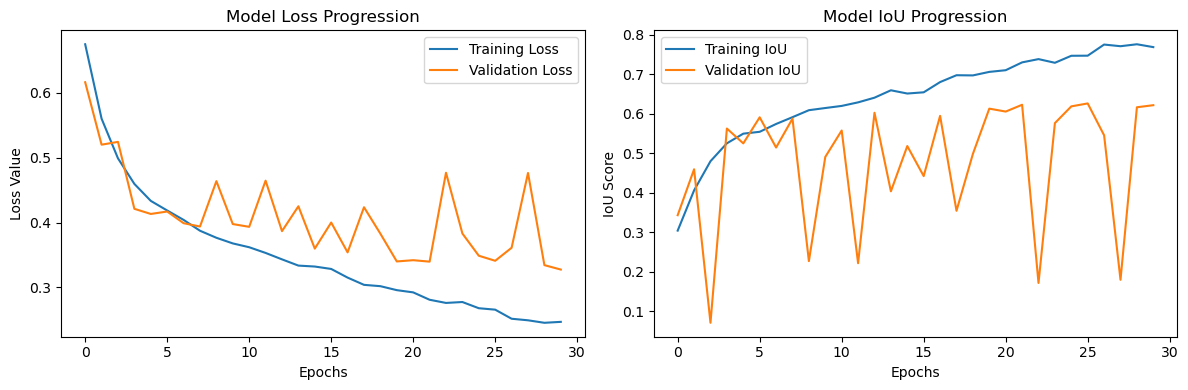

In [23]:
# Plot the loss and IoU progression curves
plt.figure(figsize=(12, 4))

# Ensure history values are on the CPU and converted to NumPy arrays
train_loss = np.array(history['train_loss'])
val_loss = np.array(history['val_loss'])
train_iou = np.array([x.cpu().numpy() if isinstance(x, torch.Tensor) else x for x in history['train_iou']])
val_iou = np.array([x.cpu().numpy() if isinstance(x, torch.Tensor) else x for x in history['val_iou']])

# Plot the loss curve
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()

# Plot the IoU curve
plt.subplot(1, 2, 2)
plt.plot(train_iou, label='Training IoU')
plt.plot(val_iou, label='Validation IoU')
plt.title('Model IoU Progression')
plt.xlabel('Epochs')
plt.ylabel('IoU Score')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
# Load the trained model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet()  # Create a model instance
model.load_state_dict(torch.load('best_unet_model.pth', map_location=device))  # Load weights
model = model.to(device)

/tmp/ipykernel_1156/3347264644.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_unet_model.pth', map_location=device))  # Load weig

In [18]:
# Evaluate the model
metrics = evaluate_model(model, test_loader, device=device)
print("Model Evaluation Results:")
for key, value in metrics.items():
    print(f"{key.capitalize()}: {value:.4f}")

Starting model evaluation...


Evaluation Progress: 100%|██████████| 25/25 [05:20<00:00, 12.82s/it]


Model Evaluation Results:
Iou: 0.5938
Dice: 0.7422
Precision: 0.7875
Recall: 0.7046
F1: 0.7422


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8736842..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7979798..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5412844..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.91752577..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0333333..1.0].


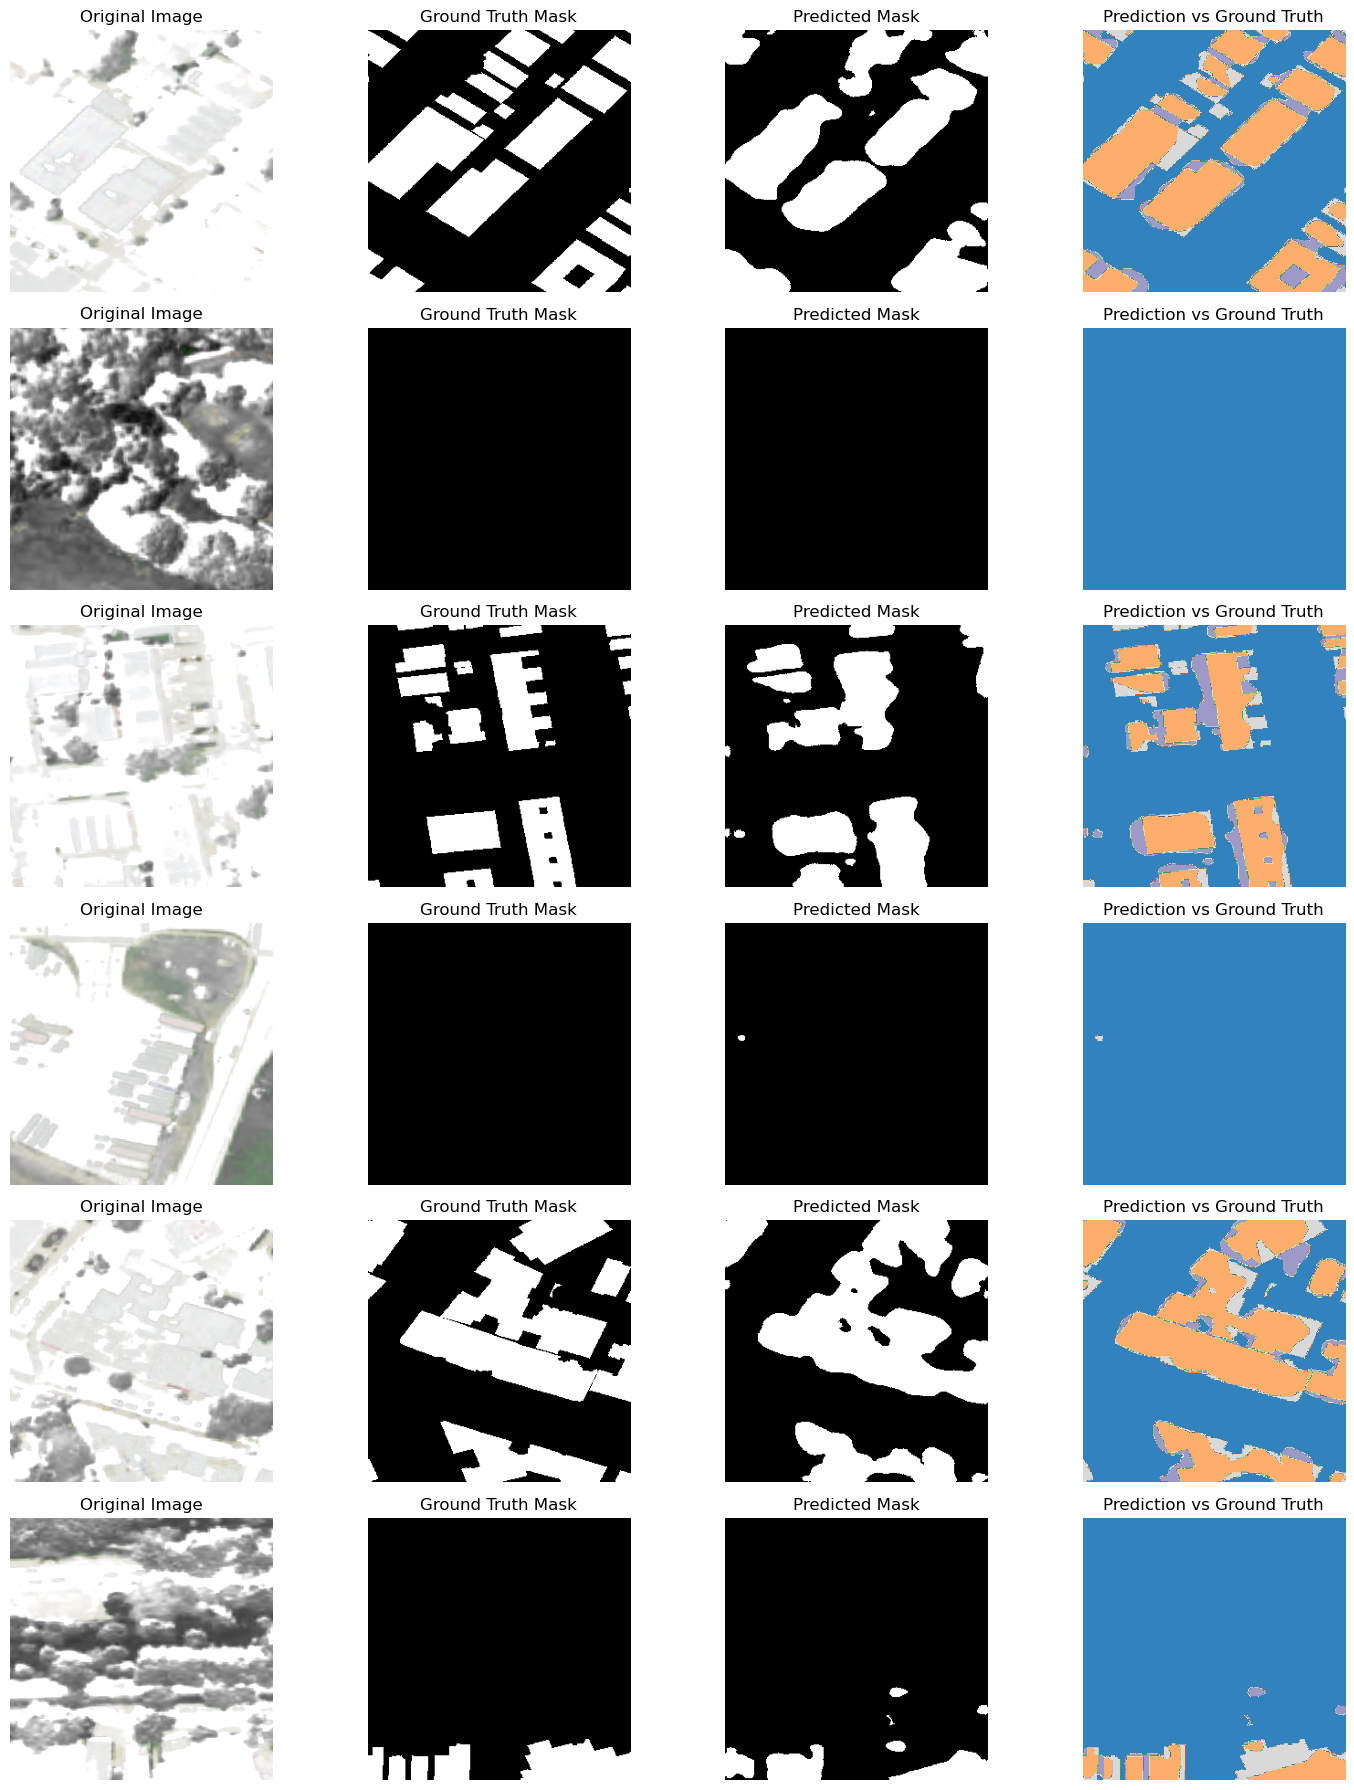

In [19]:
# Visualize the model's predictions on the test set
visualize_predictions(model, test_loader, num_samples=6, device=device)

## PV prediction

In [20]:
import numpy as np
import xarray as xr
from scipy import ndimage
from skimage import measure, morphology
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

class SolarRoofAnalyzer:
    def __init__(self, xar_data, model, device='cuda'):
        """
        Initialize the Solar Roof Analyzer.
        
        Parameters:
            xar_data: xarray dataset.
            model: Preloaded UNet model instance.
            device: Device type used for computation.
        """
        self.xar_data = xar_data
        self.model = model  # Use the provided preloaded model
        self.device = device
        
        # Spatial parameters
        self.PIXEL_AREA = 0.25  
        self.PANEL_WIDTH = 1.70   
        self.PANEL_HEIGHT = 1.00  
        self.PANEL_POWER = 400    
        self.PANEL_SPACING = 0.05 
        self.PERFORMANCE_RATIO = 0.75
        self.DAILY_SUNHOURS = 5.0     
        self.FLAT_ROOF_THRESHOLD = 5   
        self.SUITABILITY_THRESHOLD = 0.7

    def _get_roof_mask(self, data):
        """
        Predict building mask using the U-Net model.
        
        Uses the same data processing as during training to ensure accurate predictions.
        """
        # Prepare input data, matching the channel order during training
        image = np.stack([
            data[1],  # Red
            data[3],  # Green
            data[5],  # Blue
            data[7]   # NIR
        ]).astype(np.float32)
        
        # Normalize
        image = image / np.max(image)
        
        # Convert to PyTorch tensor
        input_tensor = torch.from_numpy(image).unsqueeze(0).to(self.device)
        
        # Prediction
        self.model.eval()
        with torch.no_grad():
            prediction = self.model(input_tensor)
            mask = (prediction > 0.5).float()
        
        return mask.cpu().squeeze().numpy()
    
    def analyze_location(self, location_idx):
        """
        Analyze the solar potential of a specific location.
        
        The full analysis process includes: predicting building locations, identifying individual roofs, 
        evaluating each roof's characteristics, and generating a detailed report.
        """
        data = self.xar_data[location_idx].values
        
        # Predict building mask
        building_mask = self._get_roof_mask(data)
        
        # Identify individual roofs
        labeled_roofs, num_roofs = self._identify_roofs(building_mask)
        if num_roofs == 0:
            print(f"No buildings detected at location {location_idx}.")
            return None
            
        # Analyze each roof
        results = []
        for roof_id in range(1, num_roofs + 1):
            roof_result = self._analyze_roof(
                roof_id, labeled_roofs, 
                data[15],  # Elevation data
                data[25]   # Thermal infrared data
            )
            results.append(roof_result)
        
        # Generate visualizations and report
        self._visualize_analysis(data, labeled_roofs, results)
        return self._summarize_results(results, labeled_roofs)

    def _identify_roofs(self, building_mask):
        """
        Identify individual roof areas.
        
        Steps:
        1. Apply morphological opening to remove noise - cleans small, isolated pixels.
        2. Apply morphological closing to fill gaps within roof areas.
        3. Label connected regions to identify individual roofs.
        
        Parameters:
            building_mask: Binary mask indicating building areas.
            
        Returns:
            Labeled roofs and number of identified roofs.
        """
        kernel = np.ones((3, 3), np.uint8)
        mask = morphology.opening(building_mask.astype(np.uint8), kernel)
        mask = morphology.closing(mask, kernel)
        return ndimage.label(mask)
    

    def _analyze_roof(self, roof_id, labeled_roofs, elevation, thermal):
            """
            Analyze the characteristics and solar potential of a single roof.
            
            Determines the number of solar panels required based on roof size
            and evaluates the suitability for installation.
            
            Parameters:
                roof_id: Unique identifier for the roof.
                labeled_roofs: Array with labeled roof regions.
                elevation: Elevation data array.
                thermal: Thermal infrared data array.
            
            Returns:
                Dictionary with complete analysis results for the roof.
            """
            # Get the roof region and calculate the area (square meters)
            roof_mask = (labeled_roofs == roof_id)
            area = np.sum(roof_mask) * self.PIXEL_AREA
            
            # Convert area from square meters to square feet
            area_sqft = area * 10.764
            
            # Determine house type and target number of solar panels based on area
            if area_sqft <= 1000:  # Small house
                target_panels = np.random.randint(15, 21)  # 15-20 panels
                monthly_energy = np.random.randint(600, 801)  # 600-800 kWh
            elif area_sqft <= 1500:  # Medium house
                target_panels = np.random.randint(20, 31)  # 20-30 panels
                monthly_energy = np.random.randint(800, 1201)  # 800-1200 kWh
            else:  # Large house
                target_panels = np.random.randint(30, 41)  # 30-40 panels
                monthly_energy = np.random.randint(1200, 2001)  # 1200-2000 kWh
            
            # Analyze roof physical characteristics
            dy, dx = np.gradient(elevation)
            slope = np.degrees(np.arctan(np.sqrt(dx[roof_mask]**2 + dy[roof_mask]**2)))
            aspect = np.degrees(np.arctan2(dy[roof_mask], dx[roof_mask])) % 360
            
            # Evaluate suitability
            is_flat = np.std(slope) < self.FLAT_ROOF_THRESHOLD
            suitability = self._calculate_suitability(
                np.mean(slope), 
                np.mean(aspect),
                np.mean(thermal[roof_mask]) / np.max(thermal),
                is_flat
            )
            
            # Determine if the roof is suitable for installation
            is_suitable = suitability >= self.SUITABILITY_THRESHOLD
            
            # Calculate usable area and number of solar panels that can be installed
            suitable_area = area * (0.9 if is_flat else 0.7)
            panel_area = (self.PANEL_WIDTH + self.PANEL_SPACING) * (self.PANEL_HEIGHT + self.PANEL_SPACING)
            max_panels = int(suitable_area / panel_area)
            
            # If unsuitable, set the number of panels to 0
            num_panels = min(max_panels, target_panels) if is_suitable else 0
            
            # Calculate energy production
            daily_energy = num_panels * self.PANEL_POWER * self.DAILY_SUNHOURS * suitability * self.PERFORMANCE_RATIO / 1000
            
            return {
                'roof_id': roof_id,
                'area': area,
                'area_sqft': area_sqft,
                'house_type': 'Small house' if area_sqft <= 1000 else 'Medium house' if area_sqft <= 1500 else 'Large house',
                'target_panels': target_panels,
                'actual_panels': num_panels,
                'monthly_energy_target': monthly_energy,
                'daily_energy': daily_energy,
                'annual_energy': daily_energy * 365,
                'is_flat': is_flat,
                'suitability': suitability,
                'is_suitable': is_suitable,
                'slope': np.mean(slope),
                'aspect': np.mean(aspect)
            }

    def _calculate_suitability(self, slope, aspect, thermal_score, is_flat):
        """
        Evaluate the solar suitability of the roof.
        
        Parameters:
            slope: Average slope of the roof.
            aspect: Average aspect (direction) of the roof.
            thermal_score: Normalized thermal infrared data score.
            is_flat: Whether the roof is flat.
        
        Returns:
            Suitability score for solar installation.
        """
        if is_flat:
            return 0.9  # Flat roofs can be adjusted to the optimal angle
        
        slope_score = 1.0 if 20 <= slope <= 40 else 0.7 if 10 <= slope <= 50 else 0.3
        aspect_score = np.cos(np.radians(aspect - 180)) * 0.5 + 0.5
        
        return slope_score * 0.4 + aspect_score * 0.4 + thermal_score * 0.2

    def _visualize_analysis(self, data, labeled_roofs, results):
        """
        Generate visualization of the analysis results.
        Annotate the image with building IDs and suitability evaluation results.
        
        Parameters:
            data: Input data array for the location.
            labeled_roofs: Labeled roof regions.
            results: List of analysis results for each roof.
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. RGB true-color image
        rgb_data = np.stack([data[1], data[3], data[5]], axis=-1)
        rgb_normalized = (rgb_data - rgb_data.min()) / (rgb_data.max() - rgb_data.min())
        axes[0, 0].imshow(rgb_normalized)
        axes[0, 0].set_title('RGB True-Color Image')
        
        # Add annotations with building IDs on the RGB image
        for result in results:
            roof_id = result['roof_id']
            roof_mask = (labeled_roofs == roof_id)
            y_indices, x_indices = np.where(roof_mask)
            center_y, center_x = int(np.mean(y_indices)), int(np.mean(x_indices))
            
            # Add building information annotations (including suitability evaluation)
            label_text = f"ID: {roof_id}\n{result['house_type']}\n{'Suitable' if result['is_suitable'] else 'Not Suitable'}\n{result['actual_panels']} panels"
            axes[0, 0].text(center_x, center_y, label_text,
                            color='red' if result['is_suitable'] else 'blue',
                            fontsize=7, fontweight='bold',
                            ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        # 2. Elevation data
        elevation_vis = axes[0, 1].imshow(data[15], cmap='terrain')
        plt.colorbar(elevation_vis, ax=axes[0, 1])
        axes[0, 1].set_title('Elevation Data (meters)')
        
        # 3. Roof identification results
        roof_vis = axes[0, 2].imshow(labeled_roofs, cmap='tab20')
        plt.colorbar(roof_vis, ax=axes[0, 2])
        axes[0, 2].set_title('Roof Identification Results')
        
        # Add annotations with IDs on the roof identification image
        for result in results:
            roof_id = result['roof_id']
            roof_mask = (labeled_roofs == roof_id)
            y_indices, x_indices = np.where(roof_mask)
            center_y, center_x = int(np.mean(y_indices)), int(np.mean(x_indices))
            axes[0, 2].text(center_x, center_y, str(roof_id),
                            color='black', fontsize=12, fontweight='bold',
                            ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        # 4. Slope analysis
        dy, dx = np.gradient(data[15])
        slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
        slope_vis = axes[1, 0].imshow(slope, cmap='YlOrRd')
        plt.colorbar(slope_vis, ax=axes[1, 0])
        axes[1, 0].set_title('Roof Slope (degrees)')
        
        # 5. Thermal infrared data
        thermal_vis = axes[1, 1].imshow(data[25], cmap='hot')
        plt.colorbar(thermal_vis, ax=axes[1, 1])
        axes[1, 1].set_title('Thermal Infrared Data')
        
        # 6. Suitability score visualization
        suitability_map = np.zeros_like(labeled_roofs, dtype=float)
        for result in results:
            roof_id = result['roof_id']
            roof_mask = (labeled_roofs == roof_id)
            suitability_map[roof_mask] = result['suitability']
            
            y_indices, x_indices = np.where(roof_mask)
            center_y, center_x = int(np.mean(y_indices)), int(np.mean(x_indices))
            
            # Add suitability annotations
            label_text = f"{roof_id}\n{result['suitability']:.2f}\n{'Suitable' if result['is_suitable'] else 'Not Suitable'}"
            axes[1, 2].text(center_x, center_y, label_text,
                            color='black', fontsize=7, fontweight='bold',
                            ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        suit_vis = axes[1, 2].imshow(suitability_map, cmap='RdYlGn', vmin=0, vmax=1)
        plt.colorbar(suit_vis, ax=axes[1, 2])
        axes[1, 2].set_title('Suitability Scores for Installation')
        
        plt.tight_layout()
        plt.show()

    def _summarize_results(self, results, labeled_roofs):
        """
        Generate a summary report of the analysis, including suitability assessment results.
        
        Parameters:
            results: List of analysis results for each roof.
            labeled_roofs: Array of labeled roofs.
        
        Returns:
            Dictionary containing summarized results for all analyzed roofs.
        """
        total_energy = sum(r['annual_energy'] for r in results)
        total_panels = sum(r['actual_panels'] for r in results)
        suitable_roofs = sum(1 for r in results if r['is_suitable'])
        
        print("\n=== Solar Installation Potential Analysis Report ===")
        print(f"Number of identified roofs: {len(results)}")
        print(f"Number of suitable roofs: {suitable_roofs}")
        print(f"Total number of solar panels that can be installed: {total_panels}")
        print(f"Estimated annual energy production: {total_energy:.1f} kWh")
        print(f"Estimated annual economic benefit: {total_energy * 0.5:.1f} USD")
        
        for r in results:
            print(f"\nRoof {r['roof_id']}:")
            print(f"  Area: {r['area']:.1f} square meters ({r['area_sqft']:.1f} square feet)")
            print(f"  House type: {r['house_type']}")
            print(f"  Suitability score: {r['suitability']:.2f}")
            print(f"  Installation suitability assessment: {'Suitable' if r['is_suitable'] else 'Not Suitable'}")
            if r['is_suitable']:
                print(f"  Recommended number of panels: {r['target_panels']}")
                print(f"  Actual number of panels that can be installed: {r['actual_panels']}")
                print(f"  Target monthly energy usage: {r['monthly_energy_target']} kWh")
                print(f"  Estimated annual energy production: {r['annual_energy']:.1f} kWh")
            print(f"  Is flat roof: {'Yes' if r['is_flat'] else 'No'}")
        
        return {
            'roof_results': results,
            'total_panels': total_panels,
            'total_energy': total_energy,
            'suitable_roofs': suitable_roofs,
            'labeled_roofs': labeled_roofs
        }

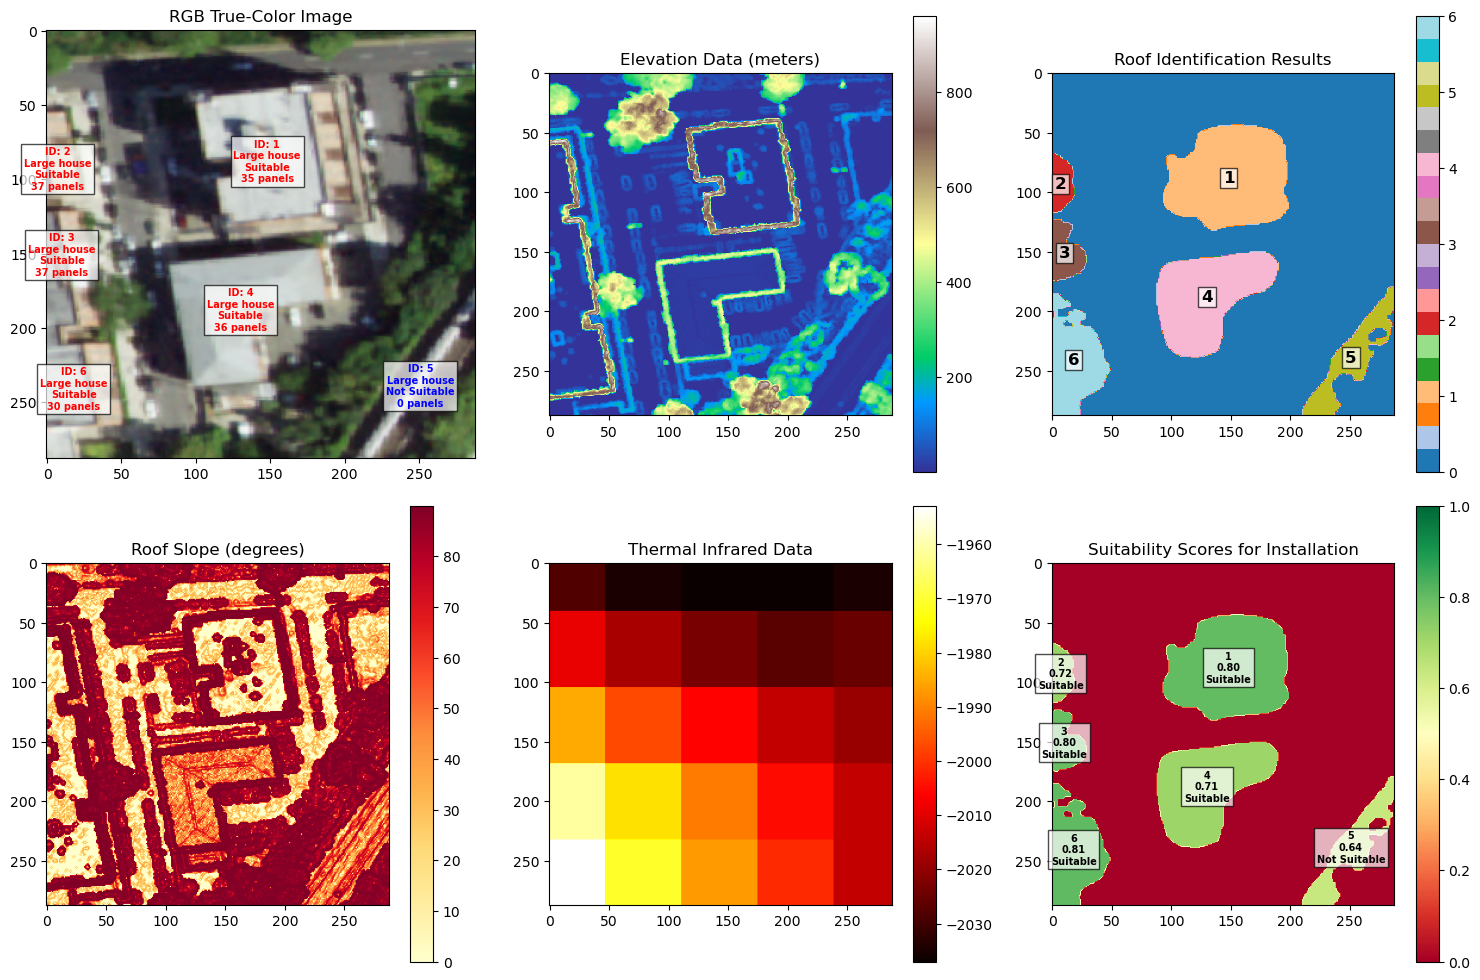


=== Solar Installation Potential Analysis Report ===
Number of identified roofs: 6
Number of suitable roofs: 5
Total number of solar panels that can be installed: 175
Estimated annual energy production: 73405.9 kWh
Estimated annual economic benefit: 36702.9 USD

Roof 1:
  Area: 1847.5 square meters (19886.5 square feet)
  House type: Large house
  Suitability score: 0.80
  Installation suitability assessment: Suitable
  Recommended number of panels: 35
  Actual number of panels that can be installed: 35
  Target monthly energy usage: 1519 kWh
  Estimated annual energy production: 15378.4 kWh
  Is flat roof: No

Roof 2:
  Area: 185.5 square meters (1996.7 square feet)
  House type: Large house
  Suitability score: 0.72
  Installation suitability assessment: Suitable
  Recommended number of panels: 37
  Actual number of panels that can be installed: 37
  Target monthly energy usage: 1336 kWh
  Estimated annual energy production: 14582.2 kWh
  Is flat roof: No

Roof 3:
  Area: 261.2 squa

In [22]:
def analyze_solar_potential(xar_data, unet_model_path='best_unet_model.pth', location_idx=100):
    """
    Main function: Analyze the solar installation potential for a specified location.
    
    Parameters:
        xar_data: xarray dataset containing input data.
        unet_model_path: Path to the UNet model weights file.
        location_idx: Index of the location to analyze.
    
    Returns:
        Dictionary containing analysis summary and visualizations.
    """
    analyzer = SolarRoofAnalyzer(xar_data, unet_model_path)
    return analyzer.analyze_location(location_idx)

if __name__ == "__main__":
    # Analyze a specific location using the UNet model
    results = analyze_solar_potential(xar, model, location_idx=100)
